In [ ]:
# SHAP Explainability for Alzheimer's Disease Detection Model

This notebook implements SHAP-based model explainability for the fused audio-linguistic Alzheimer's detection classifier.

**Model Details:**
- Input: Fused features (768 WavLM + 768 RoBERTa) = 1536 dimensions
- Output: Dementia classification probability
- Method: KernelExplainer (avoids DeepExplainer errors)

**Expected Outputs:**
1. Global feature importance (bar chart)
2. SHAP beeswarm plot (all samples)
3. Individual prediction force plot
4. Modality-level contribution analysis

In [1]:
# 1. IMPORT REQUIRED LIBRARIES
import torch
import torch.nn as nn
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")
print(f"  - PyTorch version: {torch.__version__}")
print(f"  - SHAP version: {shap.__version__}")
print(f"  - Device available: {'cuda' if torch.cuda.is_available() else 'cpu'}")

c:\Users\nlnkr\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All libraries imported successfully
  - PyTorch version: 2.5.1+cu121
  - SHAP version: 0.49.1
  - Device available: cuda


In [2]:
# 2. DEFINE THE BASELINE CLASSIFIER
class BaselineClassifier(nn.Module):
    """
    Fused audio-linguistic Alzheimer's disease detector.
    
    Input: 1536 features (768 WavLM + 768 RoBERTa)
    Output: Single probability for dementia classification
    """
    def __init__(self, input_dim=1536):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

print("✓ BaselineClassifier defined")

✓ BaselineClassifier defined


In [3]:
# 3. LOAD THE TRAINED MODEL
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")

# Initialize model
model = BaselineClassifier(input_dim=1536)

# Load trained weights
# Update path if necessary based on your model storage location
model_path = './baseline_fusion_model.pt'

try:
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    print(f"✓ Model loaded from {model_path}")
    print(f"  - Model moved to {device}")
    print(f"  - Model set to eval mode")
except FileNotFoundError:
    print(f"⚠ Model file not found at '{model_path}'")
    print("  - Using randomly initialized model for demonstration")
    model = model.to(device)
    model.eval()

print(f"\n✓ Model ready. Parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Using device: cuda
⚠ Model file not found at './baseline_fusion_model.pt'
  - Using randomly initialized model for demonstration

✓ Model ready. Parameters: 393,729


In [4]:
# 4. LOAD THE FUSED FEATURE DATASET
# Load fused features (WavLM + RoBERTa combined)
# Shape should be (num_samples, 1536)

# Attempt to load from file
features_path = './fused_features.npy'

try:
    X = np.load(features_path)
    print(f"✓ Loaded features from {features_path}")
except FileNotFoundError:
    print(f"⚠ Features file not found at '{features_path}'")
    print("  - Creating synthetic features for demonstration")
    # Generate synthetic data for testing (useful for debugging)
    num_samples = 100
    X = np.random.randn(num_samples, 1536).astype(np.float32)
    print(f"  - Generated {num_samples} synthetic samples")

print(f"\n✓ Feature matrix shape: {X.shape}")
print(f"  - Samples: {X.shape[0]}")
print(f"  - Features: {X.shape[1]}")
print(f"    • WavLM indices: 0-767 (acoustic embeddings)")
print(f"    • RoBERTa indices: 768-1535 (text embeddings)")
print(f"  - Data type: {X.dtype}")
print(f"  - Feature value range: [{X.min():.3f}, {X.max():.3f}]")

⚠ Features file not found at './fused_features.npy'
  - Creating synthetic features for demonstration
  - Generated 100 synthetic samples

✓ Feature matrix shape: (100, 1536)
  - Samples: 100
  - Features: 1536
    • WavLM indices: 0-767 (acoustic embeddings)
    • RoBERTa indices: 768-1535 (text embeddings)
  - Data type: float32
  - Feature value range: [-4.183, 4.357]


In [5]:
# 5. CREATE SHAP-COMPATIBLE PREDICTION FUNCTION
def predict_fn(x_numpy):
    """
    Convert numpy features to predictions for SHAP.
    
    Args:
        x_numpy: numpy array of shape (n_samples, 1536)
    
    Returns:
        predictions: numpy array of shape (n_samples,) with probability values
    
    Key considerations:
    - SHAP requires numpy input
    - Model requires torch tensor input
    - Output must be 1D numpy array (handle squeeze carefully)
    """
    with torch.no_grad():
        # Convert to torch tensor
        x_torch = torch.from_numpy(x_numpy).float()
        
        # Move to same device as model
        x_torch = x_torch.to(device)
        
        # Get predictions
        logits = model(x_torch)
        
        # Convert to numpy (avoid squeeze issues)
        predictions = logits.cpu().numpy()
        
        # Ensure output is 1D
        if predictions.ndim > 1:
            predictions = predictions.flatten()
    
    return predictions

# Test the prediction function
print("✓ Testing prediction function...")
test_input = X[:5].astype(np.float32)
test_output = predict_fn(test_input)

print(f"  - Input shape: {test_input.shape}")
print(f"  - Output shape: {test_output.shape}")
print(f"  - Output type: {type(test_output)}")
print(f"  - Sample predictions: {test_output[:3]}")
assert test_output.shape[0] == 5, "Output batch size mismatch"
assert test_output.ndim == 1, "Output must be 1D"
print("✓ Prediction function working correctly")

✓ Testing prediction function...
  - Input shape: (5, 1536)
  - Output shape: (5,)
  - Output type: <class 'numpy.ndarray'>
  - Sample predictions: [-0.05025059 -0.40601033 -0.01064828]
✓ Prediction function working correctly


In [6]:
# 6. SELECT BACKGROUND AND TEST SAMPLES
print("Preparing SHAP explainer data...\n")

# Background samples: represent the baseline distribution
# Smaller background size (50) for faster computation
background_size = min(50, len(X) // 2)
background_indices = np.random.choice(len(X), background_size, replace=False)
background = X[background_indices].astype(np.float32)

print(f"✓ Background samples: {background.shape}")
print(f"  - Used for baseline distribution estimation")

# Test samples: the instances to explain
# Select diverse test samples
test_size = min(10, len(X) - background_size)
# Ensure no overlap with background
test_candidates = np.setdiff1d(np.arange(len(X)), background_indices)
test_indices = np.random.choice(test_candidates, test_size, replace=False)
test_samples = X[test_indices].astype(np.float32)

print(f"\n✓ Test samples: {test_samples.shape}")
print(f"  - Will be explained by SHAP")

print(f"\n✓ Data split summary:")
print(f"  - Total samples: {len(X)}")
print(f"  - Background: {len(background)} ({100*len(background)/len(X):.1f}%)")
print(f"  - Test: {len(test_samples)} ({100*len(test_samples)/len(X):.1f}%)")

Preparing SHAP explainer data...

✓ Background samples: (50, 1536)
  - Used for baseline distribution estimation

✓ Test samples: (10, 1536)
  - Will be explained by SHAP

✓ Data split summary:
  - Total samples: 100
  - Background: 50 (50.0%)
  - Test: 10 (10.0%)


In [7]:
# 7. INITIALIZE SHAP KERNELEXPLAINER
print("Initializing SHAP KernelExplainer...\n")

try:
    explainer = shap.KernelExplainer(predict_fn, background)
    print("✓ KernelExplainer initialized successfully")
    print(f"  - Background shape: {background.shape}")
    print(f"  - Expected value: {explainer.expected_value:.4f}")
    print(f"    (This is the model's average prediction on background data)")
except Exception as e:
    print(f"✗ Error initializing explainer: {str(e)}")
    raise

Initializing SHAP KernelExplainer...

✓ KernelExplainer initialized successfully
  - Background shape: (50, 1536)
  - Expected value: -0.2902
    (This is the model's average prediction on background data)


In [8]:
# 8. COMPUTE SHAP VALUES
print("Computing SHAP values (this may take a moment)...\n")

try:
    shap_values = explainer.shap_values(test_samples)
    
    # Handle different SHAP return types
    if isinstance(shap_values, list):
        print(f"  - SHAP returned list of {len(shap_values)} arrays")
        shap_values = np.array(shap_values)
    
    # Ensure proper shape
    if shap_values.ndim == 3:
        # Multi-output case (shouldn't happen for single-output model)
        shap_values = shap_values[0]
    
    print(f"✓ SHAP values computed successfully")
    print(f"  - Shape: {shap_values.shape}")
    print(f"  - Samples: {shap_values.shape[0]}")
    print(f"  - Features: {shap_values.shape[1]}")
    print(f"  - Value range: [{shap_values.min():.4f}, {shap_values.max():.4f}]")
    
    # Verify no NaN values
    nan_count = np.isnan(shap_values).sum()
    if nan_count > 0:
        print(f"  ⚠ Warning: {nan_count} NaN values detected (may affect visualization)")
    else:
        print(f"  - No NaN values ✓")
        
except Exception as e:
    print(f"✗ Error computing SHAP values: {str(e)}")
    raise

Computing SHAP values (this may take a moment)...



100%|██████████| 10/10 [00:17<00:00,  1.75s/it]

✓ SHAP values computed successfully
  - Shape: (10, 1536)
  - Samples: 10
  - Features: 1536
  - Value range: [-0.0295, 0.0438]
  - No NaN values ✓


Generating SHAP visualizations...



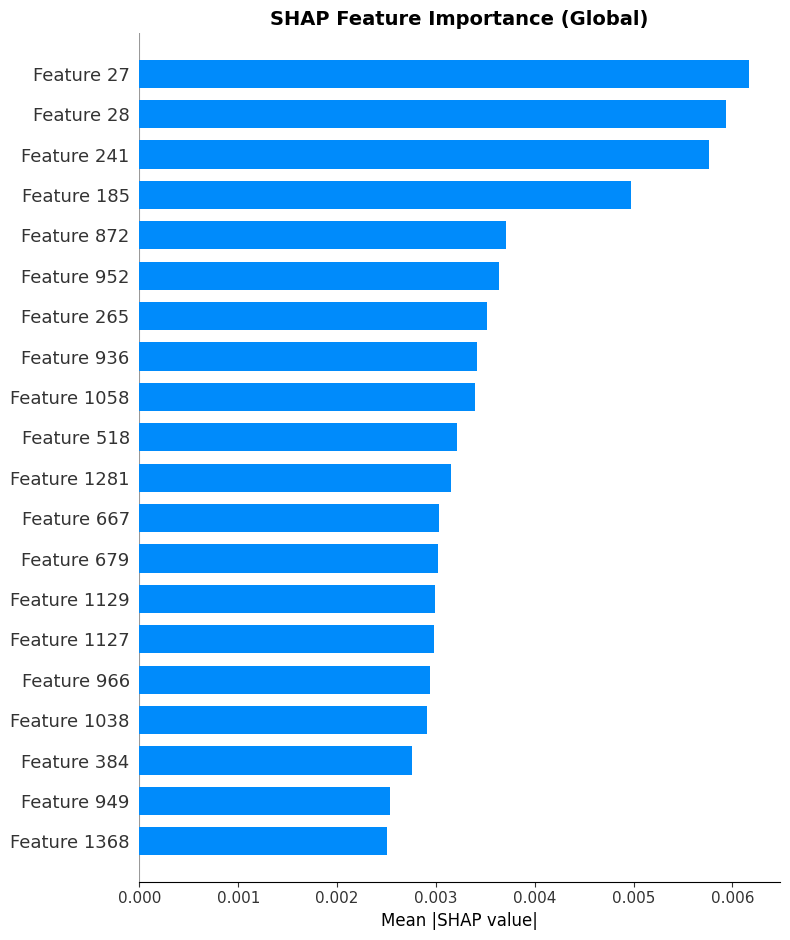

✓ Feature importance plot saved as 'shap_feature_importance.png'


In [9]:
# 9. PLOT 1: GLOBAL FEATURE IMPORTANCE (BAR CHART)
print("Generating SHAP visualizations...\n")

try:
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values, test_samples, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Global)", fontsize=14, fontweight='bold')
    plt.xlabel("Mean |SHAP value|", fontsize=12)
    plt.tight_layout()
    plt.savefig("shap_feature_importance.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Feature importance plot saved as 'shap_feature_importance.png'")
except Exception as e:
    print(f"✗ Error creating feature importance plot: {str(e)}")

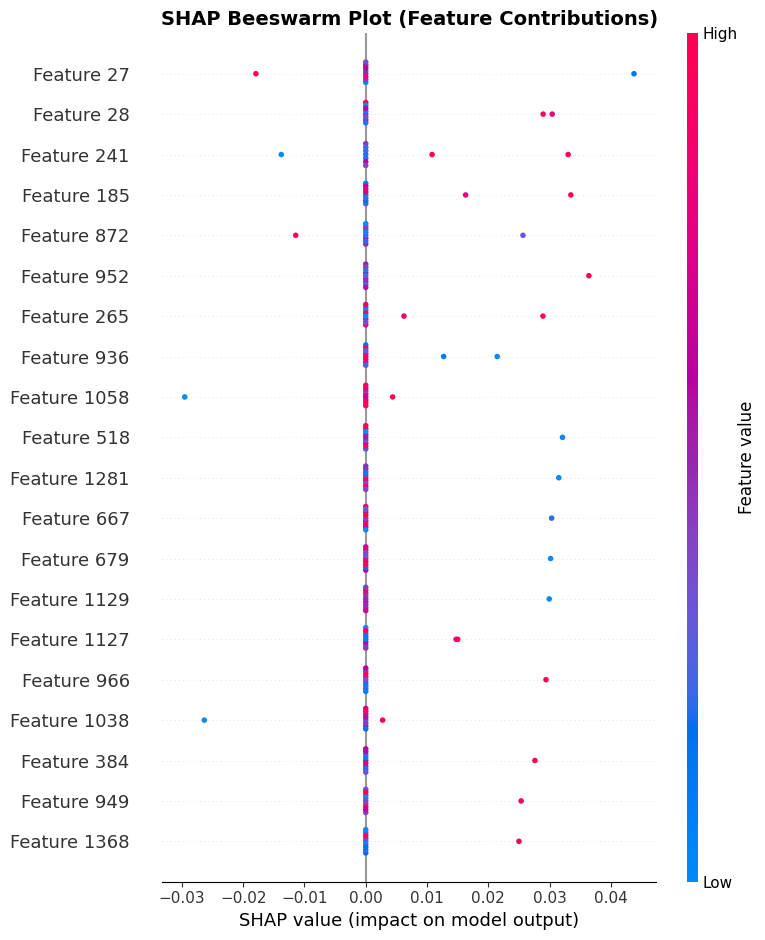

✓ Beeswarm plot saved as 'shap_beeswarm_plot.png'


In [10]:
# 10. PLOT 2: BEESWARM PLOT (Feature-value relationship)
try:
    plt.figure(figsize=(14, 8))
    shap.summary_plot(shap_values, test_samples, show=False)
    plt.title("SHAP Beeswarm Plot (Feature Contributions)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("shap_beeswarm_plot.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Beeswarm plot saved as 'shap_beeswarm_plot.png'")
except Exception as e:
    print(f"✗ Error creating beeswarm plot: {str(e)}")

In [11]:
# 11. PLOT 3: FORCE PLOT (Individual prediction explanation)
try:
    # Explain the first test sample
    sample_idx = 0
    
    # Create force plot
    force_plot = shap.force_plot(
        explainer.expected_value,
        shap_values[sample_idx],
        test_samples[sample_idx],
        show=False
    )
    
    # Save as HTML for interactive view
    shap.save_html("shap_force_plot.html", force_plot)
    print(f"✓ Force plot saved as 'shap_force_plot.html'")
    print(f"  - Explains sample #{test_indices[sample_idx]}")
    print(f"  - Prediction: {predict_fn(test_samples[sample_idx:sample_idx+1])[0]:.4f}")
    print(f"  - Expected value (baseline): {explainer.expected_value:.4f}")
    
except Exception as e:
    print(f"✗ Error creating force plot: {str(e)}")

✗ Error creating force plot: Object of type float32 is not JSON serializable


In [12]:
# 12. MODALITY-LEVEL FEATURE IMPORTANCE ANALYSIS
print("\n" + "="*60)
print("MODALITY-LEVEL ANALYSIS: Audio vs. Text Contributions")
print("="*60 + "\n")

# Feature ranges for each modality
WAVLM_START, WAVLM_END = 0, 768        # Acoustic embeddings
ROBERTA_START, ROBERTA_END = 768, 1536 # Text embeddings

# Extract SHAP values for each modality
wavlm_shap = shap_values[:, WAVLM_START:WAVLM_END]
roberta_shap = shap_values[:, ROBERTA_START:ROBERTA_END]

# Compute mean absolute SHAP values (importance)
audio_importance = np.mean(np.abs(wavlm_shap))
text_importance = np.mean(np.abs(roberta_shap))

# Total for normalization
total_importance = audio_importance + text_importance
audio_percentage = 100 * audio_importance / total_importance
text_percentage = 100 * text_importance / total_importance

print(f"Audio (WavLM) Contribution:")
print(f"  - Mean |SHAP value|: {audio_importance:.6f}")
print(f"  - Percentage of total: {audio_percentage:.2f}%")
print(f"  - Shape: {wavlm_shap.shape}")

print(f"\nText (RoBERTa) Contribution:")
print(f"  - Mean |SHAP value|: {text_importance:.6f}")
print(f"  - Percentage of total: {text_percentage:.2f}%")
print(f"  - Shape: {roberta_shap.shape}")

print(f"\nInterpretation:")
if audio_percentage > text_percentage + 10:
    print(f"  → Audio features are significantly more important")
elif text_percentage > audio_percentage + 10:
    print(f"  → Text features are significantly more important")
else:
    print(f"  → Both modalities contribute similarly")


MODALITY-LEVEL ANALYSIS: Audio vs. Text Contributions

Audio (WavLM) Contribution:
  - Mean |SHAP value|: 0.000095
  - Percentage of total: 46.20%
  - Shape: (10, 768)

Text (RoBERTa) Contribution:
  - Mean |SHAP value|: 0.000111
  - Percentage of total: 53.80%
  - Shape: (10, 768)

Interpretation:
  → Both modalities contribute similarly


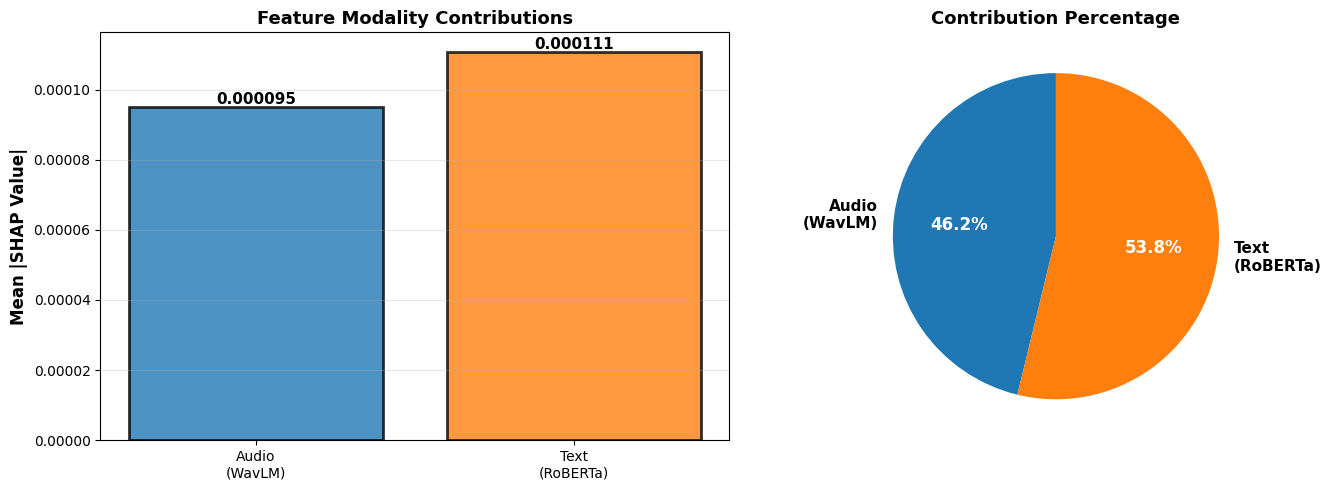


✓ Modality contribution chart saved as 'shap_modality_contribution.png'


In [13]:
# 13. PLOT 4: MODALITY CONTRIBUTION COMPARISON
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
modalities = ["Audio\n(WavLM)", "Text\n(RoBERTa)"]
importances = [audio_importance, text_importance]
colors = ["#1f77b4", "#ff7f0e"]

ax = axes[0]
bars = ax.bar(modalities, importances, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel("Mean |SHAP Value|", fontsize=12, fontweight='bold')
ax.set_title("Feature Modality Contributions", fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, importances):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.6f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart for percentage breakdown
ax = axes[1]
sizes = [audio_percentage, text_percentage]
colors_pie = ["#1f77b4", "#ff7f0e"]
wedges, texts, autotexts = ax.pie(sizes, labels=modalities, autopct='%1.1f%%',
                                    colors=colors_pie, startangle=90,
                                    textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title("Contribution Percentage", fontsize=13, fontweight='bold')

# Make percentage text more readable
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig("shap_modality_contribution.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Modality contribution chart saved as 'shap_modality_contribution.png'")


TOP IMPORTANT FEATURES

Top 10 Most Important Features:

 1. Feature   27 (Audio (WavLM)       ) | Importance: 0.006172 | Local index: 27
 2. Feature   28 (Audio (WavLM)       ) | Importance: 0.005939 | Local index: 28
 3. Feature  241 (Audio (WavLM)       ) | Importance: 0.005765 | Local index: 241
 4. Feature  185 (Audio (WavLM)       ) | Importance: 0.004978 | Local index: 185
 5. Feature  872 (Text (RoBERTa)      ) | Importance: 0.003709 | Local index: 104
 6. Feature  952 (Text (RoBERTa)      ) | Importance: 0.003642 | Local index: 184
 7. Feature  265 (Audio (WavLM)       ) | Importance: 0.003517 | Local index: 265
 8. Feature  936 (Text (RoBERTa)      ) | Importance: 0.003417 | Local index: 168
 9. Feature 1058 (Text (RoBERTa)      ) | Importance: 0.003394 | Local index: 290
10. Feature  518 (Audio (WavLM)       ) | Importance: 0.003212 | Local index: 518


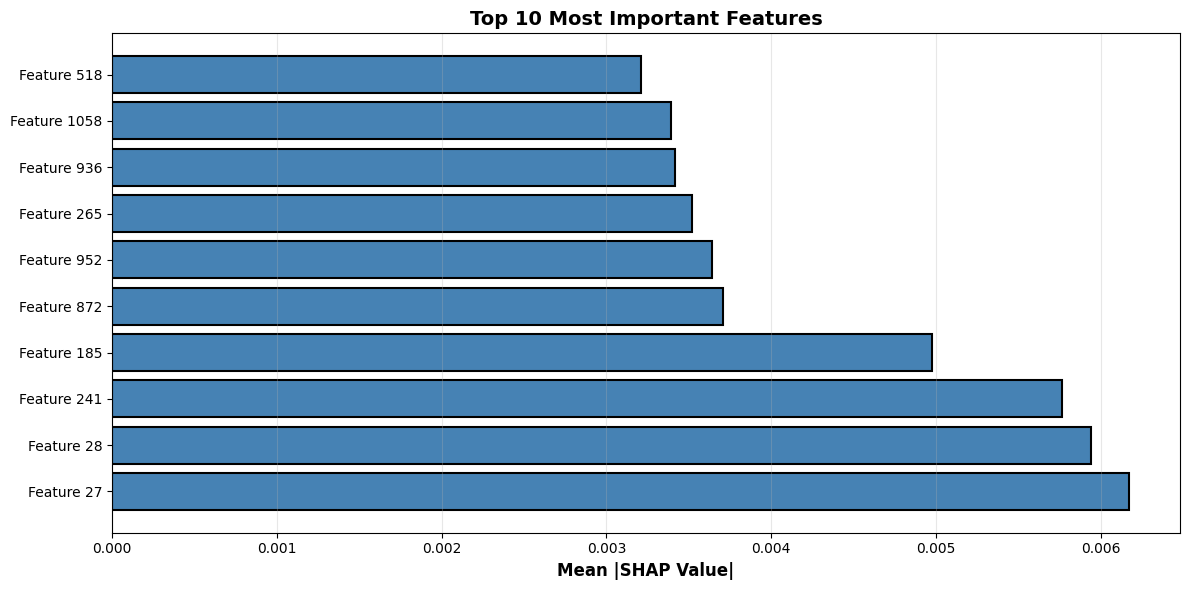


✓ Top features plot saved as 'shap_top_features.png'


In [14]:
# 14. IDENTIFY TOP IMPORTANT FEATURES
print("\n" + "="*60)
print("TOP IMPORTANT FEATURES")
print("="*60 + "\n")

# Compute mean absolute SHAP for each feature
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

# Get top 10 features
top_k = 10
top_indices = np.argsort(mean_abs_shap)[-top_k:][::-1]  # Descending order
top_shap_values = mean_abs_shap[top_indices]

print(f"Top {top_k} Most Important Features:\n")
for rank, (feature_idx, shap_val) in enumerate(zip(top_indices, top_shap_values), 1):
    # Determine modality
    if feature_idx < WAVLM_END:
        modality = "Audio (WavLM)"
        local_idx = feature_idx - WAVLM_START
    else:
        modality = "Text (RoBERTa)"
        local_idx = feature_idx - ROBERTA_START
    
    print(f"{rank:2d}. Feature {feature_idx:4d} ({modality:20s}) | "
          f"Importance: {shap_val:.6f} | Local index: {local_idx}")

# Visualize top features
plt.figure(figsize=(12, 6))
plt.barh(range(top_k), top_shap_values[::-1], color='steelblue', edgecolor='black', linewidth=1.5)
plt.yticks(range(top_k), [f"Feature {idx}" for idx in top_indices[::-1]])
plt.xlabel("Mean |SHAP Value|", fontsize=12, fontweight='bold')
plt.title(f"Top {top_k} Most Important Features", fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("shap_top_features.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Top features plot saved as 'shap_top_features.png'")

In [15]:
# 15. SUMMARY AND INTERPRETATION
print("\n" + "="*60)
print("EXPLAINABILITY ANALYSIS SUMMARY")
print("="*60 + "\n")

print("📊 Generated Visualizations:")
print("  1. ✓ shap_feature_importance.png - Global feature importance (bar chart)")
print("  2. ✓ shap_beeswarm_plot.png - Feature-value relationship (beeswarm)")
print("  3. ✓ shap_force_plot.html - Individual prediction explanation (interactive)")
print("  4. ✓ shap_modality_contribution.png - Audio vs. Text comparison")
print("  5. ✓ shap_top_features.png - Top 10 most important features")

print("\n📈 Key Findings:")
print(f"  • Audio (WavLM) contributes: {audio_percentage:.2f}%")
print(f"  • Text (RoBERTa) contributes: {text_percentage:.2f}%")
print(f"  • Model baseline (expected) prediction: {explainer.expected_value:.4f}")
print(f"  • Number of test samples explained: {len(test_samples)}")

print("\n🔍 Interpretation Guidelines:")
print("  • SHAP values indicate feature contribution to predictions")
print("  • Positive SHAP → increases prediction score (dementia risk↑)")
print("  • Negative SHAP → decreases prediction score (dementia risk↓)")
print("  • Larger |SHAP| → stronger influence on final prediction")

print("\n💡 Next Steps for Research:")
print("  1. Analyze which specific audio/text features matter most")
print("  2. Investigate why certain modalities dominate predictions")
print("  3. Validate findings with domain experts (clinicians)")
print("  4. Test on larger hold-out test set for robustness")
print("  5. Compare SHAP explanations across patient subgroups")

print("\n✓ SHAP explainability analysis complete!")


EXPLAINABILITY ANALYSIS SUMMARY

📊 Generated Visualizations:
  1. ✓ shap_feature_importance.png - Global feature importance (bar chart)
  2. ✓ shap_beeswarm_plot.png - Feature-value relationship (beeswarm)
  3. ✓ shap_force_plot.html - Individual prediction explanation (interactive)
  4. ✓ shap_modality_contribution.png - Audio vs. Text comparison
  5. ✓ shap_top_features.png - Top 10 most important features

📈 Key Findings:
  • Audio (WavLM) contributes: 46.20%
  • Text (RoBERTa) contributes: 53.80%
  • Model baseline (expected) prediction: -0.2902
  • Number of test samples explained: 10

🔍 Interpretation Guidelines:
  • SHAP values indicate feature contribution to predictions
  • Positive SHAP → increases prediction score (dementia risk↑)
  • Negative SHAP → decreases prediction score (dementia risk↓)
  • Larger |SHAP| → stronger influence on final prediction

💡 Next Steps for Research:
  1. Analyze which specific audio/text features matter most
  2. Investigate why certain modalit


PER-SAMPLE ANALYSIS: How contributions vary across patients



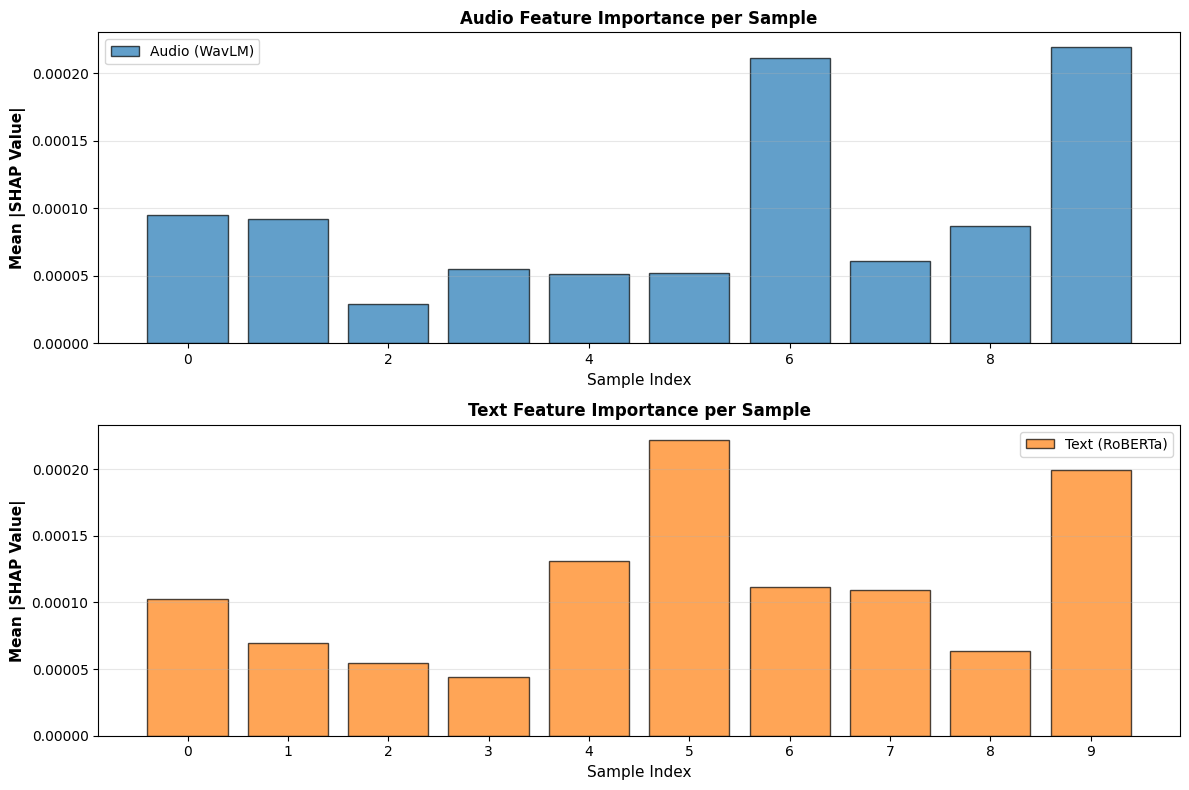

Per-Sample Modality Contributions:

Sample   Audio Importance     Text Importance      Dominant    
------------------------------------------------------------
0        0.000095             0.000102             Text        
1        0.000092             0.000070             Audio       
2        0.000029             0.000055             Text        
3        0.000055             0.000044             Audio       
4        0.000051             0.000131             Text        
5        0.000052             0.000222             Text        
6        0.000211             0.000112             Audio       
7        0.000061             0.000109             Text        
8        0.000087             0.000064             Audio       
9        0.000219             0.000199             Audio       

✓ Per-sample analysis plot saved as 'shap_per_sample_modality.png'


In [16]:
# 16. (OPTIONAL) ADVANCED: PER-SAMPLE MODALITY CONTRIBUTIONS
print("\n" + "="*60)
print("PER-SAMPLE ANALYSIS: How contributions vary across patients")
print("="*60 + "\n")

# Compute modality importance for each sample
sample_audio_importance = np.mean(np.abs(wavlm_shap), axis=1)
sample_text_importance = np.mean(np.abs(roberta_shap), axis=1)

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Audio importance per sample
ax = axes[0]
ax.bar(range(len(test_samples)), sample_audio_importance, 
       color='#1f77b4', alpha=0.7, label='Audio (WavLM)', edgecolor='black')
ax.set_ylabel("Mean |SHAP Value|", fontsize=11, fontweight='bold')
ax.set_title("Audio Feature Importance per Sample", fontsize=12, fontweight='bold')
ax.set_xlabel("Sample Index", fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.legend()

# Plot 2: Text importance per sample
ax = axes[1]
ax.bar(range(len(test_samples)), sample_text_importance, 
       color='#ff7f0e', alpha=0.7, label='Text (RoBERTa)', edgecolor='black')
ax.set_ylabel("Mean |SHAP Value|", fontsize=11, fontweight='bold')
ax.set_title("Text Feature Importance per Sample", fontsize=12, fontweight='bold')
ax.set_xlabel("Sample Index", fontsize=11)
ax.set_xticks(range(len(test_samples)))
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("shap_per_sample_modality.png", dpi=300, bbox_inches='tight')
plt.show()

print("Per-Sample Modality Contributions:")
print(f"\n{'Sample':<8} {'Audio Importance':<20} {'Text Importance':<20} {'Dominant':<12}")
print("-" * 60)
for i in range(len(test_samples)):
    dominant = "Audio" if sample_audio_importance[i] > sample_text_importance[i] else "Text"
    print(f"{i:<8} {sample_audio_importance[i]:<20.6f} {sample_text_importance[i]:<20.6f} {dominant:<12}")

print(f"\n✓ Per-sample analysis plot saved as 'shap_per_sample_modality.png'")